# Day 14 — Cats vs Dogs with Transfer Learning (MobileNetV2)

**The idea in one sentence:** instead of teaching a computer to see from zero,
we borrow a model that already learned to see from 1.4 million photos, and we
only teach it the one new thing we care about — *cat or dog?*

| | |
|---|---|
| Dataset | `cats_vs_dogs` from TensorFlow Datasets (23,262 images) |
| Backbone | MobileNetV2, pre-trained on ImageNet, **frozen** |
| My head | GlobalAveragePooling → Dropout(0.2) → Dense(1, sigmoid) |
| Phase 1 | Train the head only (feature extraction) |
| Phase 2 | Unfreeze the top of MobileNetV2 and fine-tune with a tiny learning rate |
| Target | ≥ 90% validation accuracy, 93%+ preferred |

Run the cells top to bottom. On CPU the whole notebook takes about an hour.

## 0. Imports and settings

In [1]:
import os, time, json
from pathlib import Path

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow_datasets as tfds

print("TensorFlow", tf.__version__)
print("Keras     ", keras.__version__)
print("TFDS      ", tfds.__version__)

keras.utils.set_random_seed(42)   # same random numbers every run

IMG_SIZE = 160        # every picture becomes 160x160
BATCH_SIZE = 32       # 32 pictures at a time
EPOCHS_PHASE1 = 5     # train the head
EPOCHS_PHASE2 = 3     # fine-tune
FINE_TUNE_FROM = 100  # unfreeze MobileNetV2 layers from index 100 onwards
CLASS_NAMES = ["cat", "dog"]

IMAGES = Path("images"); IMAGES.mkdir(exist_ok=True)
OUTPUTS = Path("outputs"); OUTPUTS.mkdir(exist_ok=True)

TensorFlow 2.21.0
Keras      3.15.1
TFDS       4.9.10


## 1. Load the dataset

TFDS ships Cats vs Dogs as **one** split called `train`. We slice it ourselves:

* `train[:80%]` → training set
* `train[80%:]` → validation set

`as_supervised=True` means "hand me `(image, label)` pairs" instead of a dictionary.

In [2]:
(train_raw, val_raw), info = tfds.load(
    "cats_vs_dogs",
    split=["train[:80%]", "train[80%:]"],
    with_info=True,
    as_supervised=True,
)

n_total = info.splits["train"].num_examples
n_train = int(train_raw.cardinality())
n_val   = int(val_raw.cardinality())

print(f"Total images      : {n_total:,}")
print(f"Training images   : {n_train:,}")
print(f"Validation images : {n_val:,}")
print(f"Classes           : {info.features['label'].names}")

Total images      : 23,262
Training images   : 18,610
Validation images : 4,652
Classes           : ['cat', 'dog']


> The original Kaggle dataset has 25,000 pictures. TFDS silently drops 1,738
> corrupted files, which is why we see 23,262.

## 2. Look at the data

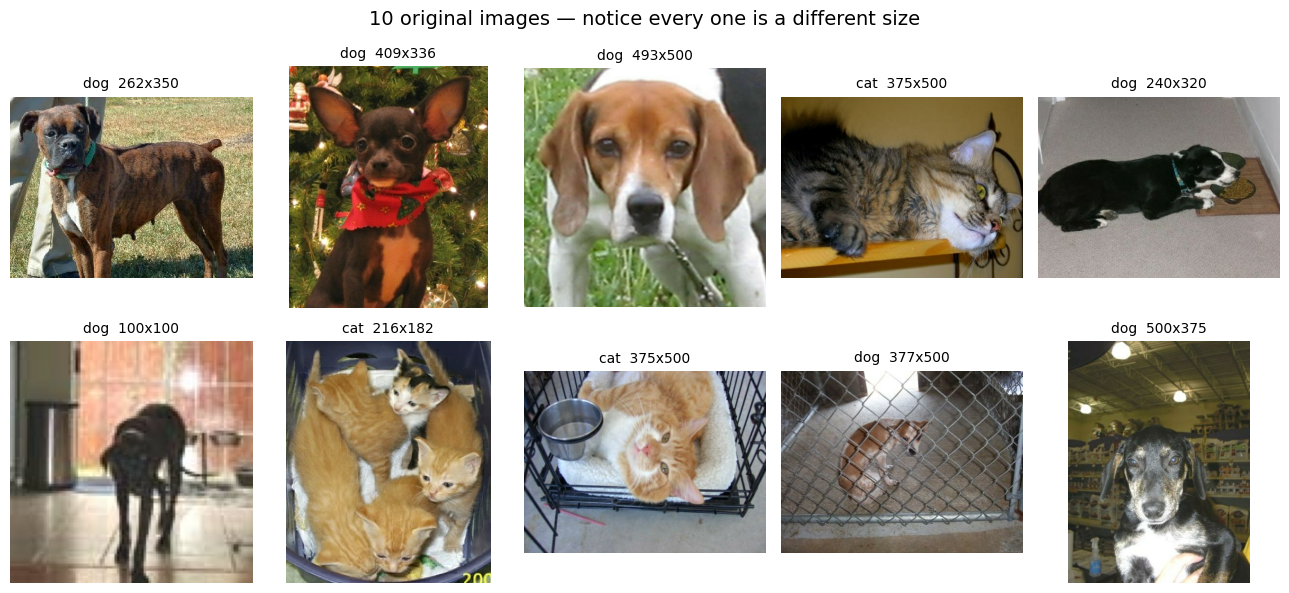

In [3]:
plt.figure(figsize=(13, 6))
for i, (image, label) in enumerate(train_raw.take(10)):
    plt.subplot(2, 5, i + 1)
    plt.imshow(image.numpy())
    plt.title(f"{CLASS_NAMES[int(label)]}  {image.shape[0]}x{image.shape[1]}", fontsize=10)
    plt.axis("off")
plt.suptitle("10 original images — notice every one is a different size", fontsize=14)
plt.tight_layout()
plt.show()

## 3. Preprocess: resize → shuffle → batch → prefetch

Neural networks need every input to be exactly the same shape, so the first job
is resizing. We do **not** divide by 255 here — a `Rescaling` layer inside the
model will do that. Doing it in both places would be a bug.

In [4]:
AUTOTUNE = tf.data.AUTOTUNE

def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    return image, label

train_ds = (train_raw
            .map(preprocess, num_parallel_calls=AUTOTUNE)
            .shuffle(1000)
            .batch(BATCH_SIZE)
            .prefetch(AUTOTUNE))

val_ds = (val_raw
          .map(preprocess, num_parallel_calls=AUTOTUNE)
          .batch(BATCH_SIZE)
          .prefetch(AUTOTUNE))

for images, labels in train_ds.take(1):
    print("batch of images :", images.shape, images.dtype)
    print("batch of labels :", labels.shape, labels.dtype)
    print("pixel range     :", float(tf.reduce_min(images)), "..", float(tf.reduce_max(images)))
print("train batches:", len(train_ds), " val batches:", len(val_ds))

batch of images : (32, 160, 160, 3) <dtype: 'float32'>
batch of labels : (32,) <dtype: 'int64'>
pixel range     : 0.0 .. 255.0
train batches: 582  val batches: 146


## 4. Data augmentation

Augmentation shows the model slightly changed copies of each picture — flipped,
rotated, zoomed — so it learns *dog-ness* instead of memorising exact pixels.
Keras runs these layers **only during training** and switches them off automatically
when predicting.

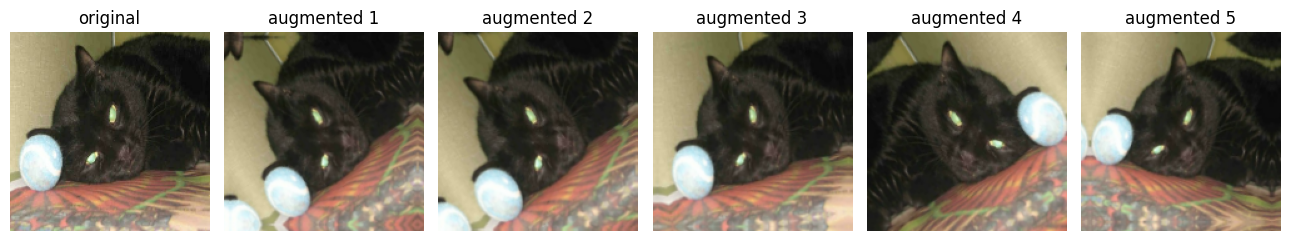

In [5]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
], name="data_augmentation")

plt.figure(figsize=(13, 3))
for images, _ in train_ds.take(1):
    first = images[0]
    plt.subplot(1, 6, 1); plt.imshow(first.numpy().astype("uint8"))
    plt.title("original"); plt.axis("off")
    for i in range(5):
        aug = data_augmentation(tf.expand_dims(first, 0), training=True)[0]
        plt.subplot(1, 6, i + 2)
        plt.imshow(tf.clip_by_value(aug, 0, 255).numpy().astype("uint8"))
        plt.title(f"augmented {i+1}"); plt.axis("off")
plt.tight_layout(); plt.show()

## 5. Build the model

Three arguments do all the work:

* `weights="imagenet"` — download everything MobileNetV2 learned from 1.4M photos
* `include_top=False` — leave off its original 1000-class output layer, we need 2 classes
* `base_model.trainable = False` — **freeze**: do not change those numbers during training

In [6]:
base_model = keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet",
)
base_model.trainable = False

print("layers    :", len(base_model.layers))
print("parameters:", f"{base_model.count_params():,}")
print("output    :", base_model.output_shape, "  <- a description of the picture, not pixels")

layers    : 154
parameters: 2,257,984
output    : (None, 5, 5, 1280)   <- a description of the picture, not pixels


In [7]:
inputs  = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="input_image")
x = data_augmentation(inputs)
x = layers.Rescaling(1./127.5, offset=-1, name="rescale_to_minus1_1")(x)  # 0..255 -> -1..1
x = base_model(x, training=False)                                        # (5, 5, 1280)
x = layers.GlobalAveragePooling2D(name="global_avg_pool")(x)             # (1280,)
x = layers.Dropout(0.2, name="dropout")(x)
outputs = layers.Dense(1, activation="sigmoid", name="cat_or_dog")(x)    # one number: P(dog)

model = keras.Model(inputs, outputs, name="cats_vs_dogs_transfer")
model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3),
              loss="binary_crossentropy",
              metrics=["accuracy"])
model.summary()

total_params = model.count_params()
trainable_params = sum(int(tf.size(w)) for w in model.trainable_weights)
print(f"\nTrainable: {trainable_params:,} of {total_params:,} "
      f"({100*trainable_params/total_params:.2f}%) — we borrow the rest")

Model: "cats_vs_dogs_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescale_to_minus1_1 (Rescaling) │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg_pool                 │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cat_or_dog (Dense)              │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)


Trainable: 1,281 of 2,259,265 (0.06%) — we borrow the rest


## 6. Phase 1 — train the head only (feature extraction)

MobileNetV2 is frozen. Only the 1,281 weights in my `Dense` layer change.

In [8]:
loss0, acc0 = model.evaluate(val_ds, verbose=0)
print(f"Before training: val accuracy = {acc0*100:.2f}%  (a coin flip — nothing learned yet)")

Before training: val accuracy = 55.07%  (a coin flip — nothing learned yet)


In [9]:
t0 = time.time()
history1 = model.fit(train_ds, epochs=EPOCHS_PHASE1, validation_data=val_ds)
print(f"Phase 1 took {(time.time()-t0)/60:.1f} minutes")

Epoch 1/5


c:\Users\Mg\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


582/582 ━━━━━━━━━━━━━━━━━━━━ 297s 489ms/step - accuracy: 0.9502 - loss: 0.1282 - val_accuracy: 0.9832 - val_loss: 0.0515
Epoch 2/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 308s 528ms/step - accuracy: 0.9652 - loss: 0.0890 - val_accuracy: 0.9837 - val_loss: 0.0496
Epoch 3/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 216s 369ms/step - accuracy: 0.9673 - loss: 0.0846 - val_accuracy: 0.9841 - val_loss: 0.0460
Epoch 4/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 206s 353ms/step - accuracy: 0.9672 - loss: 0.0850 - val_accuracy: 0.9850 - val_loss: 0.0444
Epoch 5/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 214s 367ms/step - accuracy: 0.9682 - loss: 0.0836 - val_accuracy: 0.9839 - val_loss: 0.0466
Phase 1 took 20.7 minutes


## 7. Phase 2 — fine-tuning

Now we unfreeze the **top** of MobileNetV2 (its most specialised layers) and keep
training with a learning rate **100× smaller**. Small steps only — the point is to
nudge the borrowed knowledge towards cats and dogs, not to overwrite it.

Two rules that are easy to get wrong:

1. **You must re-`compile()`** after changing `trainable`, or nothing changes.
2. **Keep every `BatchNormalization` layer frozen.** They carry running averages
   from ImageNet; letting them update on small batches destroys accuracy.

In [10]:
base_model.trainable = True
for layer in base_model.layers[:FINE_TUNE_FROM]:
    layer.trainable = False
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-5),   # 100x smaller
              loss="binary_crossentropy",
              metrics=["accuracy"])

print("unfrozen layers:", sum(1 for l in base_model.layers if l.trainable), "of", len(base_model.layers))
print("trainable params:", f"{sum(int(tf.size(w)) for w in model.trainable_weights):,}")

unfrozen layers: 36 of 154
trainable params: 1,840,897


In [ ]:
t0 = time.time()
history2 = model.fit(train_ds,
                     epochs=EPOCHS_PHASE1 + EPOCHS_PHASE2,
                     initial_epoch=len(history1.epoch),
                     validation_data=val_ds)
print(f"Phase 2 took {(time.time()-t0)/60:.1f} minutes")

hist = {k: list(history1.history[k]) + list(history2.history[k]) for k in history1.history}

Epoch 6/8
582/582 ━━━━━━━━━━━━━━━━━━━━ 401s 677ms/step - accuracy: 0.9727 - loss: 0.0733 - val_accuracy: 0.9871 - val_loss: 0.0403
Epoch 7/8
  5/582 ━━━━━━━━━━━━━━━━━━━━ 8:57 931ms/step - accuracy: 0.9438 - loss: 0.1037

## 8. Evaluate

In [ ]:
train_loss, train_acc = model.evaluate(train_ds, verbose=0)
val_loss,   val_acc   = model.evaluate(val_ds,   verbose=0)

print(f"Training   accuracy : {train_acc*100:.2f}%   loss {train_loss:.4f}")
print(f"Validation accuracy : {val_acc*100:.2f}%   loss {val_loss:.4f}")
print(f"Gap                 : {(train_acc-val_acc)*100:+.2f} points")
print(f"90% minimum: {'PASS' if val_acc >= 0.90 else 'FAIL'}   93% target: {'PASS' if val_acc >= 0.93 else 'FAIL'}")

## 9. Accuracy and loss curves

In [ ]:
epochs_range = range(1, len(hist["accuracy"]) + 1)
switch = EPOCHS_PHASE1 + 0.5

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(epochs_range, hist["accuracy"], "o-", label="Training accuracy")
axes[0].plot(epochs_range, hist["val_accuracy"], "s-", label="Validation accuracy")
axes[0].axvline(switch, color="red", ls="--", alpha=.7)
axes[0].set_title("Model Accuracy"); axes[0].set_xlabel("Epoch"); axes[0].legend(); axes[0].grid(alpha=.3)

axes[1].plot(epochs_range, hist["loss"], "o-", label="Training loss")
axes[1].plot(epochs_range, hist["val_loss"], "s-", label="Validation loss")
axes[1].axvline(switch, color="red", ls="--", alpha=.7)
axes[1].set_title("Model Loss"); axes[1].set_xlabel("Epoch"); axes[1].legend(); axes[1].grid(alpha=.3)
plt.suptitle("Red line = fine-tuning starts")
plt.tight_layout(); plt.show()

## 10. Sample predictions

In [ ]:
all_probs, all_true, kept_images = [], [], []
for i, (images, labels) in enumerate(val_ds):
    all_probs.append(model.predict(images, verbose=0).flatten())
    all_true.append(labels.numpy())
    if i < 20:
        kept_images.append(images.numpy().astype("uint8"))

all_probs = np.concatenate(all_probs)
all_true  = np.concatenate(all_true)
all_pred  = (all_probs >= 0.5).astype(int)
kept_images = np.concatenate(kept_images)

correct = all_pred == all_true
print(f"correct {correct.sum():,} / wrong {(~correct).sum():,}  ->  {correct.mean()*100:.2f}%")

In [ ]:
def show(indices, title):
    n = min(len(indices), 10)
    plt.figure(figsize=(15, 7))
    for j, idx in enumerate(indices[:n]):
        plt.subplot(2, 5, j + 1)
        plt.imshow(kept_images[idx])
        p = all_probs[idx]
        conf = p*100 if p >= .5 else (1-p)*100
        ok = all_pred[idx] == all_true[idx]
        plt.title(f"pred: {CLASS_NAMES[all_pred[idx]]} ({conf:.1f}%)\ntrue: {CLASS_NAMES[all_true[idx]]}",
                  fontsize=10, color="green" if ok else "red")
        plt.axis("off")
    plt.suptitle(title, fontsize=14); plt.tight_layout(); plt.show()

rng = np.random.default_rng(42)
show(rng.choice(len(kept_images), 10, replace=False), "Sample predictions")
show(np.where(~correct[:len(kept_images)])[0], "The ones it got WRONG")

## 11. Confusion matrix

In [ ]:
cm = tf.math.confusion_matrix(all_true, all_pred, num_classes=2).numpy()
tn, fp, fn, tp = cm[0,0], cm[0,1], cm[1,0], cm[1,1]

precision = tp / (tp + fp)
recall    = tp / (tp + fn)
f1 = 2 * precision * recall / (precision + recall)
print(f"cat accuracy {tn/(tn+fp)*100:.2f}%   dog accuracy {tp/(tp+fn)*100:.2f}%")
print(f"precision {precision:.4f}  recall {recall:.4f}  F1 {f1:.4f}")

plt.figure(figsize=(6.5, 5.5))
plt.imshow(cm, cmap="Blues"); plt.colorbar()
plt.xticks([0,1], CLASS_NAMES); plt.yticks([0,1], CLASS_NAMES)
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("Confusion Matrix")
for i in range(2):
    for j in range(2):
        plt.text(j, i, f"{cm[i,j]:,}", ha="center", va="center", fontsize=18,
                 color="white" if cm[i,j] > cm.max()/2 else "black")
plt.tight_layout(); plt.show()

## 12. Save the model

In [ ]:
model.save(OUTPUTS / "cats_vs_dogs_mobilenetv2.keras")
np.savez(OUTPUTS / "history.npz", **{k: np.array(v) for k, v in hist.items()})
print("saved to outputs/")

---

## What I learned

1. **Transfer learning is borrowing, not copying.** MobileNetV2's frozen layers
   already know fur, edges and ears. I only had to teach it one new question.
2. **Freezing is one line** — `base_model.trainable = False` — and it is what
   keeps 2.2 million hard-won numbers safe from my 18,610 pictures.
3. **The head is tiny.** GlobalAveragePooling turns (5,5,1280) into 1280 numbers,
   so the classifier is 1,281 weights. Under 0.1% of the model is trained in phase 1.
4. **Fine-tuning needs a tiny learning rate.** 1e-5, not 1e-3. Big steps would
   erase what was borrowed — this is called catastrophic forgetting.
5. **Re-compile after changing `trainable`,** and keep BatchNorm frozen.